In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
import torchaudio.transforms as T
import torch
from pathlib import Path
from collections import Counter

BASE_PATH = '/kaggle/input/datasets/yasiashpot/librispeech/LibriSpeech'
SPLITS    = ['test-clean', 'dev-clean']

print("Available splits:")
for s in os.listdir(BASE_PATH):
    print(f"  {s}")

Available splits:
  test-clean
  flac_to_wav.sh
  BOOKS.TXT
  README.TXT
  dev-clean
  LICENSE.TXT
  SPEAKERS.TXT
  CHAPTERS.TXT


In [2]:
def collect_dataset_info(base_path, splits):
    records = []
    for split in splits:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            print(f"⚠️ {split} not found, skipping.")
            continue

        # Walk through speaker/chapter folders
        for speaker_id in os.listdir(split_path):
            speaker_path = os.path.join(split_path, speaker_id)
            for chapter_id in os.listdir(speaker_path):
                chapter_path = os.path.join(speaker_path, chapter_id)

                # Find the transcript file
                trans_file = os.path.join(chapter_path, f'{speaker_id}-{chapter_id}.trans.txt')
                if not os.path.exists(trans_file):
                    continue

                # Parse transcripts
                with open(trans_file) as f:
                    for line in f:
                        parts = line.strip().split(' ', 1)
                        if len(parts) != 2:
                            continue
                        utt_id, transcript = parts
                        audio_file = os.path.join(chapter_path, f'{utt_id}.flac')
                        if os.path.exists(audio_file):
                            records.append({
                                'split':      split,
                                'speaker_id': speaker_id,
                                'chapter_id': chapter_id,
                                'utt_id':     utt_id,
                                'audio_path': audio_file,
                                'transcript': transcript
                            })
    return records

records = collect_dataset_info(BASE_PATH, SPLITS)
print(f"Total utterances found: {len(records)}")
print(f"\nSample record:")
for k, v in records[0].items():
    print(f"  {k}: {v}")

Total utterances found: 5323

Sample record:
  split: test-clean
  speaker_id: 4507
  chapter_id: 16021
  utt_id: 4507-16021-0000
  audio_path: /kaggle/input/datasets/yasiashpot/librispeech/LibriSpeech/test-clean/4507/16021/4507-16021-0000.flac
  transcript: CHAPTER ONE ORIGIN


── Utterances per split ──────────────────
  test-clean: 2620 utterances
  dev-clean: 2703 utterances

── Speaker stats ─────────────────────────
  Total unique speakers : 80
  Most  talkative (top5): [('4446', 108), ('1580', 105), ('61', 104), ('5142', 102), ('3752', 101)]
  Least talkative (bot5): [('8224', 32), ('422', 36), ('2902', 38), ('4077', 39), ('3576', 41)]


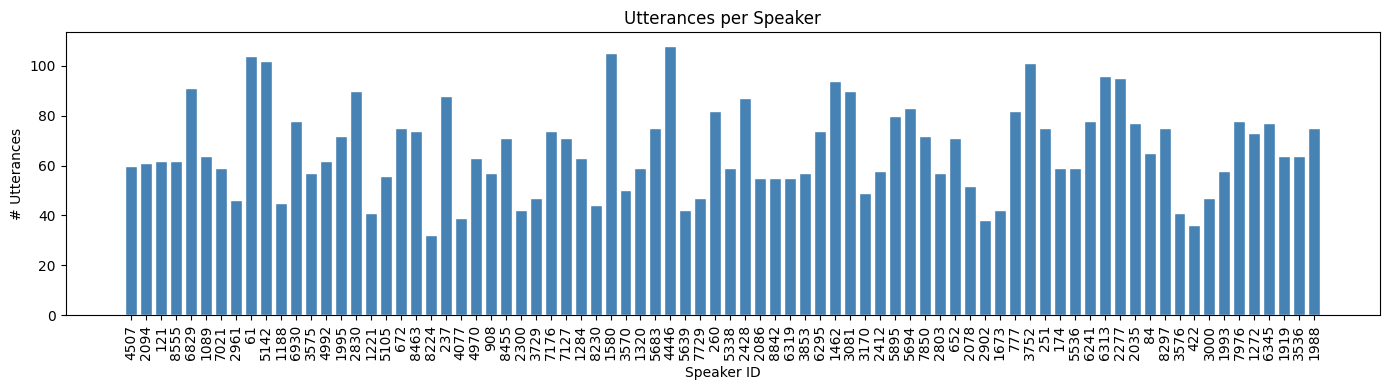

In [3]:
split_counts   = Counter(r['split']      for r in records)
speaker_counts = Counter(r['speaker_id'] for r in records)

print("── Utterances per split ──────────────────")
for split, count in split_counts.items():
    print(f"  {split}: {count} utterances")

print(f"\n── Speaker stats ─────────────────────────")
print(f"  Total unique speakers : {len(speaker_counts)}")
print(f"  Most  talkative (top5): {speaker_counts.most_common(5)}")
print(f"  Least talkative (bot5): {speaker_counts.most_common()[:-6:-1]}")

# Plot utterances per speaker
fig, ax = plt.subplots(figsize=(14, 4))
speakers = list(speaker_counts.keys())
counts   = [speaker_counts[s] for s in speakers]
ax.bar(speakers, counts, color='steelblue', edgecolor='white')
ax.set_title('Utterances per Speaker')
ax.set_xlabel('Speaker ID')
ax.set_ylabel('# Utterances')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

── Transcript stats ──────────────────────
  Avg words per utterance : 20.1
  Max words per utterance : 96
  Min words per utterance : 1
  Avg chars per utterance : 107.1

  Unique characters : [' ', "'", 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
  Vocabulary size   : 12256 unique words

  Top 20 words: [('the', 6909), ('and', 3702), ('of', 3536), ('to', 2718), ('a', 2364), ('in', 1845), ('i', 1339), ('was', 1263), ('that', 1252), ('he', 1205), ('it', 1185), ('his', 1063), ('with', 894), ('is', 837), ('for', 821), ('as', 804), ('had', 764), ('you', 761), ('but', 684), ('not', 679)]


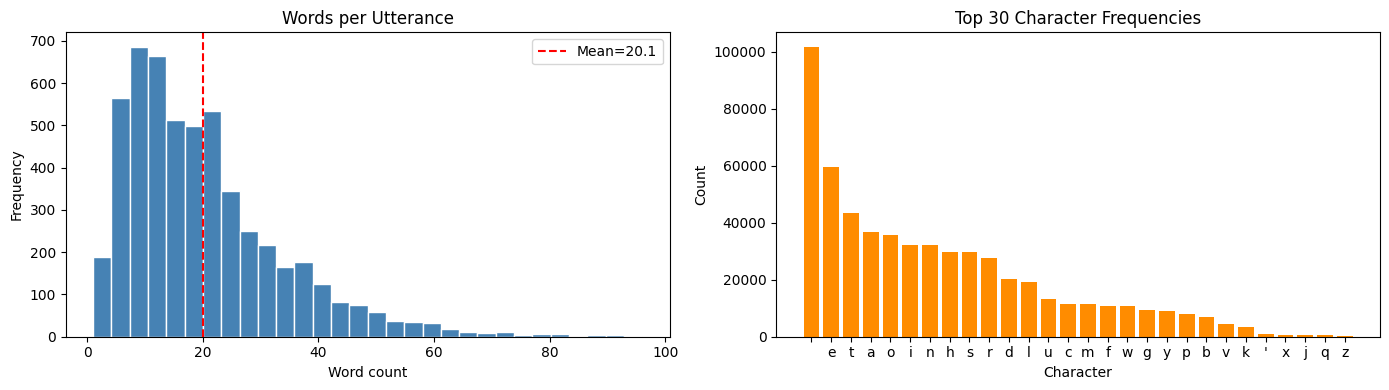

In [4]:
transcripts = [r['transcript'] for r in records]

# Character & word stats
word_counts = [len(t.split())      for t in transcripts]
char_counts = [len(t)              for t in transcripts]
all_chars   = Counter(''.join(transcripts).lower())
all_words   = Counter(' '.join(transcripts).lower().split())

print("── Transcript stats ──────────────────────")
print(f"  Avg words per utterance : {np.mean(word_counts):.1f}")
print(f"  Max words per utterance : {np.max(word_counts)}")
print(f"  Min words per utterance : {np.min(word_counts)}")
print(f"  Avg chars per utterance : {np.mean(char_counts):.1f}")
print(f"\n  Unique characters : {sorted(all_chars.keys())}")
print(f"  Vocabulary size   : {len(all_words)} unique words")
print(f"\n  Top 20 words: {all_words.most_common(20)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Word count distribution
axes[0].hist(word_counts, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Words per Utterance')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(word_counts), color='red', linestyle='--', label=f'Mean={np.mean(word_counts):.1f}')
axes[0].legend()

# Character frequency
top_chars = all_chars.most_common(30)
axes[1].bar([c[0] for c in top_chars], [c[1] for c in top_chars], color='darkorange')
axes[1].set_title('Top 30 Character Frequencies')
axes[1].set_xlabel('Character')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

── Audio duration stats (sampled) ────────
  Sample size        : 200 utterances
  Mean duration      : 6.79s
  Max duration       : 24.45s
  Min duration       : 1.95s
  Std deviation      : 4.58s
  Unique sample rates: {16000}
  Est. total hours   : 10.04h


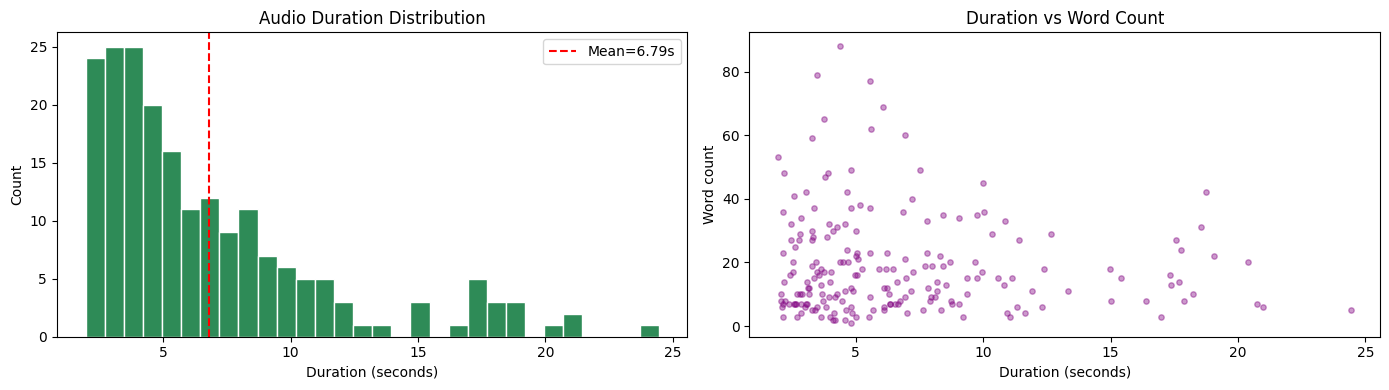

In [5]:
SAMPLE_SIZE = 200
sampled     = np.random.choice(records, size=min(SAMPLE_SIZE, len(records)), replace=False)

durations    = []
sample_rates = []

for r in sampled:
    waveform, sr = torchaudio.load(r['audio_path'])
    duration = waveform.shape[1] / sr
    durations.append(duration)
    sample_rates.append(sr)

durations   = np.array(durations)
est_hours   = (durations.sum() / 3600) * (len(records) / SAMPLE_SIZE)

print("── Audio duration stats (sampled) ────────")
print(f"  Sample size        : {SAMPLE_SIZE} utterances")
print(f"  Mean duration      : {durations.mean():.2f}s")
print(f"  Max duration       : {durations.max():.2f}s")
print(f"  Min duration       : {durations.min():.2f}s")
print(f"  Std deviation      : {durations.std():.2f}s")
print(f"  Unique sample rates: {set(sample_rates)}")
print(f"  Est. total hours   : {est_hours:.2f}h")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(durations, bins=30, color='seagreen', edgecolor='white')
axes[0].axvline(durations.mean(), color='red', linestyle='--', label=f'Mean={durations.mean():.2f}s')
axes[0].set_title('Audio Duration Distribution')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].scatter(durations,
                [len(records[np.where(sampled == r)[0][0]]['transcript'].split()) for r in sampled],
                alpha=0.4, color='purple', s=15)
axes[1].set_title('Duration vs Word Count')
axes[1].set_xlabel('Duration (seconds)')
axes[1].set_ylabel('Word count')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (257) may be set too low.
  warnings.warn(


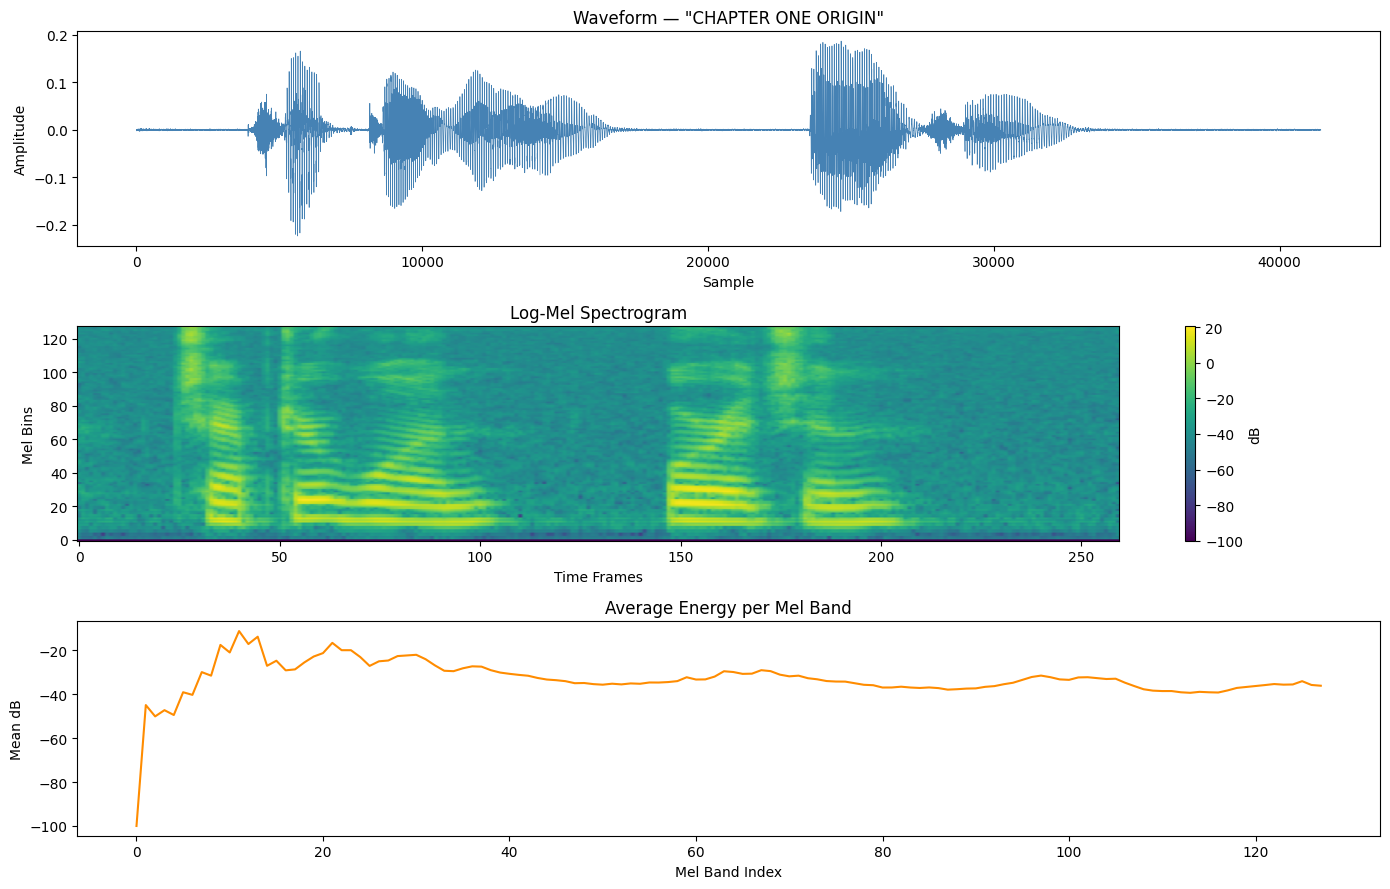


Audio: 4507-16021-0000 | Duration: 2.59s | SR: 16000Hz


In [6]:
sample = records[0]
waveform, sr = torchaudio.load(sample['audio_path'])

mel_transform = T.MelSpectrogram(sample_rate=sr, n_mels=128, n_fft=512, hop_length=160)
spec = mel_transform(waveform)
spec_db = T.AmplitudeToDB()(spec).squeeze().numpy()

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

axes[0].plot(waveform.squeeze().numpy(), color='steelblue', linewidth=0.5)
axes[0].set_title(f'Waveform — "{sample["transcript"]}"')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Amplitude')

axes[1].imshow(spec_db, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('Log-Mel Spectrogram')
axes[1].set_xlabel('Time Frames')
axes[1].set_ylabel('Mel Bins')
plt.colorbar(axes[1].images[0], ax=axes[1], label='dB')

filterbank = T.MelScale(n_mels=128, sample_rate=sr, n_stft=257)
axes[2].plot(spec_db.mean(axis=1), color='darkorange')
axes[2].set_title('Average Energy per Mel Band')
axes[2].set_xlabel('Mel Band Index')
axes[2].set_ylabel('Mean dB')

plt.tight_layout()
plt.show()
print(f"\nAudio: {sample['utt_id']} | Duration: {waveform.shape[1]/sr:.2f}s | SR: {sr}Hz")

In [7]:
class TextTransform:
    def __init__(self):
        chars = ['<blank>'] + list('abcdefghijklmnopqrstuvwxyz') + [' ', "'"]
        self.char2idx = {c: i for i, c in enumerate(chars)}
        self.idx2char = {i: c for c, i in self.char2idx.items()}
        self.blank_idx = 0

    def text_to_int(self, text):
        text = text.lower().strip()
        return [self.char2idx[c] for c in text if c in self.char2idx]

    def int_to_text(self, indices):
        return ''.join(self.idx2char.get(i, '') for i in indices if i != self.blank_idx)

    def __len__(self):
        return len(self.char2idx)

text_transform = TextTransform()
print(f'Vocabulary size: {len(text_transform)}')
print(f'Vocab: {list(text_transform.char2idx.keys())}')

# Quick sanity check
test_text = "hello world"
encoded   = text_transform.text_to_int(test_text)
decoded   = text_transform.int_to_text(encoded)
print(f'\nEncode: "{test_text}" → {encoded}')
print(f'Decode: {encoded} → "{decoded}"')

Vocabulary size: 29
Vocab: ['<blank>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', ' ', "'"]

Encode: "hello world" → [8, 5, 12, 12, 15, 27, 23, 15, 18, 12, 4]
Decode: [8, 5, 12, 12, 15, 27, 23, 15, 18, 12, 4] → "hello world"


In [8]:
import torchaudio.transforms as T

SAMPLE_RATE = 16000
N_MELS      = 128
N_FFT       = 512
HOP_LENGTH  = 160    
WIN_LENGTH  = 400    

train_audio_transform = torch.nn.Sequential(
    T.MelSpectrogram(
        sample_rate=SAMPLE_RATE,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH
    ),
    T.FrequencyMasking(freq_mask_param=15),  
    T.TimeMasking(time_mask_param=35),        
)

val_audio_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_mels=N_MELS,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    win_length=WIN_LENGTH
)

print('✅ Audio transforms defined.')

✅ Audio transforms defined.


In [9]:
import torch
from torch.utils.data import Dataset

class LibriSpeechDataset(Dataset):
    def __init__(self, records, text_transform, audio_transform):
        self.records         = records
        self.text_transform  = text_transform
        self.audio_transform = audio_transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        waveform, sr = torchaudio.load(r['audio_path'])

        if sr != SAMPLE_RATE:
            waveform = T.Resample(sr, SAMPLE_RATE)(waveform)

        spec = self.audio_transform(waveform)

        spec = (spec - spec.mean()) / (spec.std() + 1e-9)

        label = torch.tensor(
            self.text_transform.text_to_int(r['transcript']),
            dtype=torch.long
        )

        return spec, label   

train_records = [r for r in records if r['split'] == 'dev-clean']
val_records   = [r for r in records if r['split'] == 'test-clean']

train_dataset = LibriSpeechDataset(train_records, text_transform, train_audio_transform)
val_dataset   = LibriSpeechDataset(val_records,   text_transform, val_audio_transform)

print(f'Train samples : {len(train_dataset)}')
print(f'Val   samples : {len(val_dataset)}')

spec, label = train_dataset[0]
print(f'\nSample spec shape  : {spec.shape}   (channels, mel_bins, time_frames)')
print(f'Sample label       : {label}')
print(f'Sample transcript  : "{text_transform.int_to_text(label.tolist())}"')

Train samples : 2703
Val   samples : 2620

Sample spec shape  : torch.Size([1, 128, 456])   (channels, mel_bins, time_frames)
Sample label       : tensor([ 9, 20, 27,  8,  1,  4, 27, 14, 15, 27, 15, 18, 14,  1, 13,  5, 14, 20,
         1, 20,  9, 15, 14, 27,  2,  5,  9, 14,  7, 27,  5, 24,  3,  5,  5,  4,
         9, 14,  7, 12, 25, 27, 16, 12,  1,  9, 14, 27,  9, 14, 27,  1, 16, 16,
         5,  1, 18,  1, 14,  3,  5])
Sample transcript  : "it had no ornamentation being exceedingly plain in appearance"


In [10]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    specs, labels = zip(*batch)

    input_lens  = torch.tensor([s.shape[-1] for s in specs], dtype=torch.long)
    target_lens = torch.tensor([len(l)       for l in labels], dtype=torch.long)

    max_time     = input_lens.max().item()
    padded_specs = torch.zeros(len(specs), 1, N_MELS, max_time)
    for i, s in enumerate(specs):
        padded_specs[i, :, :, :s.shape[-1]] = s

    concat_labels = torch.cat(labels)

    return padded_specs, concat_labels, input_lens, target_lens


BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

specs, labels, input_lens, target_lens = next(iter(train_loader))
print(f'\nBatch spec shape   : {specs.shape}       (B, C, N_MELS, T)')
print(f'Labels shape       : {labels.shape}      (sum of all label lengths)')
print(f'Input lens (first4): {input_lens[:4]}')
print(f'Target lens (first4): {target_lens[:4]}')

Train batches : 169
Val   batches : 164

Batch spec shape   : torch.Size([16, 1, 128, 1574])       (B, C, N_MELS, T)
Labels shape       : torch.Size([1509])      (sum of all label lengths)
Input lens (first4): tensor([ 498, 1008,  884, 1574])
Target lens (first4): tensor([ 72, 147, 117, 240])


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F



SAMPLE_RATE = 16000
N_MELS      = 128
N_FFT       = 512
HOP_LENGTH  = 160
WIN_LENGTH  = 400

class LogMelSpectrogram(nn.Module):
    def __init__(self, sample_rate, n_mels, n_fft, hop_length, win_length):
        super().__init__()
        self.mel = T.MelSpectrogram(
            sample_rate=sample_rate, n_mels=n_mels,
            n_fft=n_fft, hop_length=hop_length, win_length=win_length
        )

    def forward(self, x):
        x = self.mel(x)                       
        x = torch.log(x + 1e-9)               
        x = (x - x.mean()) / (x.std() + 1e-9) 
        return x


train_audio_transform = nn.Sequential(
    LogMelSpectrogram(SAMPLE_RATE, N_MELS, N_FFT, HOP_LENGTH, WIN_LENGTH),
    T.FrequencyMasking(freq_mask_param=27),   
    T.FrequencyMasking(freq_mask_param=27),   
    T.TimeMasking(time_mask_param=70),        
    T.TimeMasking(time_mask_param=70),        
)

val_audio_transform = LogMelSpectrogram(SAMPLE_RATE, N_MELS, N_FFT, HOP_LENGTH, WIN_LENGTH)

print('✅ Improved audio transforms defined.')

✅ Improved audio transforms defined.


In [12]:
train_records = [r for r in records if r['split'] == 'dev-clean']
val_records   = [r for r in records if r['split'] == 'test-clean']

train_dataset = LibriSpeechDataset(train_records, text_transform, train_audio_transform)
val_dataset   = LibriSpeechDataset(val_records,   text_transform, val_audio_transform)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset)} samples, {len(train_loader)} batches')
print(f'Val  : {len(val_dataset)} samples, {len(val_loader)} batches')

Train: 2703 samples, 169 batches
Val  : 2620 samples, 164 batches


In [13]:
class CNNLayerNorm(nn.Module):
    def __init__(self, n_feats):
        super().__init__()
        self.layer_norm = nn.LayerNorm(n_feats)

    def forward(self, x):
        x = x.transpose(2, 3).contiguous()
        x = self.layer_norm(x)
        return x.transpose(2, 3).contiguous()


class ResidualCNN(nn.Module):
    def __init__(self, in_channels, out_channels, kernel, stride, n_feats, dropout):
        super().__init__()
        self.layer_norm1 = CNNLayerNorm(n_feats)
        self.cnn1 = nn.Conv2d(in_channels, out_channels, kernel,
                              stride=stride, padding=kernel//2)
        self.dropout1 = nn.Dropout(dropout)

        self.layer_norm2 = CNNLayerNorm(n_feats)
        self.cnn2 = nn.Conv2d(out_channels, out_channels, kernel,
                              stride=stride, padding=kernel//2)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.layer_norm1(x)
        x = F.gelu(x)
        x = self.dropout1(x)
        x = self.cnn1(x)
        x = self.layer_norm2(x)
        x = F.gelu(x)
        x = self.dropout2(x)
        x = self.cnn2(x)
        return x + residual


class BidirectionalGRU(nn.Module):
    def __init__(self, rnn_dim, hidden_size, dropout, batch_first=False):
        super().__init__()
        self.BiGRU = nn.GRU(
            input_size=rnn_dim, hidden_size=hidden_size,
            num_layers=1, batch_first=batch_first, bidirectional=True
        )
        self.layer_norm = nn.LayerNorm(rnn_dim)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x):
        x = self.layer_norm(x)
        x = F.gelu(x)
        x, _ = self.BiGRU(x)
        x = self.dropout(x)
        return x


class SpeechRecognitionModel(nn.Module):
    def __init__(self, n_cnn_layers, n_rnn_layers, rnn_dim,
                 n_class, n_feats, stride=2, dropout=0.1):
        super().__init__()

        self.cnn = nn.Conv2d(1, 32, kernel_size=3, stride=stride, padding=1)

        self.rescnn_layers = nn.Sequential(*[
            ResidualCNN(
                in_channels=32, out_channels=32, kernel=3, stride=1,
                n_feats=n_feats,
                dropout=dropout + (i * 0.05)   
            )
            for i in range(n_cnn_layers)
        ])

        self.fully_connected = nn.Linear(32 * n_feats, rnn_dim)

        self.birnn_layers = nn.Sequential(
            BidirectionalGRU(rnn_dim=rnn_dim,     hidden_size=rnn_dim,
                             dropout=dropout, batch_first=True),
            *[
                BidirectionalGRU(rnn_dim=rnn_dim * 2, hidden_size=rnn_dim,
                                 dropout=dropout, batch_first=True)
                for _ in range(n_rnn_layers - 1)
            ]
        )

        self.classifier = nn.Sequential(
            nn.Linear(rnn_dim * 2, rnn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(rnn_dim, rnn_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(rnn_dim // 2, n_class)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.rescnn_layers(x)
        B, C, freq, T = x.size()
        x = x.view(B, C * freq, T)
        x = x.transpose(1, 2)
        x = self.fully_connected(x)
        x = self.birnn_layers(x)
        x = self.classifier(x)
        return F.log_softmax(x, dim=2)


print('✅ Improved model defined.')

✅ Improved model defined.


In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

hparams = {
    'n_cnn_layers' : 3,      
    'n_rnn_layers' : 5,
    'rnn_dim'      : 384,     
    'n_class'      : len(text_transform),
    'n_feats'      : N_MELS // 2,
    'stride'       : 2,
    'dropout'      : 0.15,   
    'batch_size'   : 8,       
    'epochs'       : 50,
    'learning_rate': 3e-4,
}

torch.cuda.empty_cache()

model = SpeechRecognitionModel(
    hparams['n_cnn_layers'], hparams['n_rnn_layers'], hparams['rnn_dim'],
    hparams['n_class'],      hparams['n_feats'],      hparams['stride'],
    hparams['dropout']
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}')

train_loader = DataLoader(train_dataset, batch_size=hparams['batch_size'], shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=hparams['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')

with torch.no_grad():
    dummy = torch.randn(4, 1, N_MELS, 300).to(device)
    out   = model(dummy)
    print(f'Output shape: {out.shape}  ✅')

# Estimate GPU memory usage
print(f'\nGPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB')
print(f'GPU memory reserved : {torch.cuda.memory_reserved()  / 1e9:.2f} GB')

Device: cuda
Total parameters    : 13,634,461
Trainable parameters: 13,634,461
Train batches: 338
Output shape: torch.Size([4, 150, 29])  ✅

GPU memory allocated: 0.07 GB
GPU memory reserved : 0.20 GB


In [15]:
criterion = nn.CTCLoss(blank=text_transform.blank_idx, reduction='mean', zero_infinity=True)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=hparams['learning_rate'],
    weight_decay=1e-4
)

total_steps  = len(train_loader) * hparams['epochs']
warmup_steps = int(0.05 * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(warmup_steps, 1)
    progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f'✅ Optimizer and scheduler ready.')
print(f'   Total steps  : {total_steps}')
print(f'   Warmup steps : {warmup_steps}')

✅ Optimizer and scheduler ready.
   Total steps  : 16900
   Warmup steps : 845


In [16]:
!pip install jiwer --quiet
from jiwer import wer, cer

def greedy_decode(log_probs, input_lens, text_transform):
    pred_indices = log_probs.argmax(dim=-1).cpu().numpy()  # (B, T)
    input_lens   = input_lens.cpu().numpy()
    blank_idx    = text_transform.blank_idx
    results      = []

    for b in range(pred_indices.shape[0]):
        seq = pred_indices[b, :input_lens[b]]

        collapsed = []
        prev = None
        for idx in seq:
            if idx != blank_idx and idx != prev:
                collapsed.append(idx)
            prev = idx

        results.append(text_transform.int_to_text(collapsed))

    return results


def compute_metrics(log_probs, input_lens, targets, target_lens, text_transform):
    preds = greedy_decode(log_probs, input_lens, text_transform)

    refs  = []
    offset = 0
    for length in target_lens:
        ref_indices = targets[offset: offset + length].tolist()
        refs.append(text_transform.int_to_text(ref_indices))
        offset += length

    batch_wer = wer(refs, preds)
    batch_cer = cer(refs, preds)
    return batch_wer, batch_cer, refs, preds


print('Greedy decoder and metrics defined.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.8 MB/s eta 0:00:00:00:01
Greedy decoder and metrics defined.


In [17]:
STRIDE = 2   

def train_epoch(model, loader, criterion, optimizer, scheduler, device, text_transform):
    model.train()
    total_loss = 0
    total_wer  = 0
    total_cer  = 0
    n_batches  = 0

    for batch_idx, (specs, labels, input_lens, target_lens) in enumerate(loader):
        specs       = specs.to(device)
        labels      = labels.to(device)
        target_lens = target_lens.to(device)

        output_lens = (input_lens // STRIDE).to(device)

        optimizer.zero_grad()

        log_probs     = model(specs)                        
        log_probs_ctc = log_probs.transpose(0, 1)          

        loss = criterion(log_probs_ctc, labels, output_lens, target_lens)

        if torch.isnan(loss) or torch.isinf(loss):
            continue

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        scheduler.step()

        if batch_idx % 10 == 0:
            with torch.no_grad():
                batch_wer, batch_cer, _, _ = compute_metrics(
                    log_probs.detach(), output_lens, labels.cpu(), target_lens.cpu(), text_transform
                )
            total_wer += batch_wer
            total_cer += batch_cer

        total_loss += loss.item()
        n_batches  += 1

        if batch_idx % 50 == 0:
            print(f'    Batch [{batch_idx:>4}/{len(loader)}]  '
                  f'Loss: {loss.item():.4f}  '
                  f'LR: {scheduler.get_last_lr()[0]:.6f}')

    n_metric_batches = max(1, n_batches // 10)
    return (total_loss / max(n_batches, 1),
            total_wer  / n_metric_batches,
            total_cer  / n_metric_batches)


@torch.no_grad()
def validate_epoch(model, loader, criterion, device, text_transform, num_samples=5):
    model.eval()
    total_loss = 0
    total_wer  = 0
    total_cer  = 0
    n_batches  = 0
    sample_refs  = []
    sample_preds = []

    for specs, labels, input_lens, target_lens in loader:
        specs       = specs.to(device)
        labels      = labels.to(device)
        target_lens = target_lens.to(device)

        output_lens   = (input_lens // STRIDE).to(device)

        log_probs     = model(specs)
        log_probs_ctc = log_probs.transpose(0, 1)

        loss = criterion(log_probs_ctc, labels, output_lens, target_lens)
        if not (torch.isnan(loss) or torch.isinf(loss)):
            total_loss += loss.item()
            n_batches  += 1

        batch_wer, batch_cer, refs, preds = compute_metrics(
            log_probs, output_lens, labels.cpu(), target_lens.cpu(), text_transform
        )
        total_wer += batch_wer
        total_cer += batch_cer

        if len(sample_refs) < num_samples:
            sample_refs.extend(refs)
            sample_preds.extend(preds)

    print(f'\n    Sample predictions:')
    for ref, pred in zip(sample_refs[:num_samples], sample_preds[:num_samples]):
        print(f'      REF : "{ref}"')
        print(f'      PRED: "{pred}"')
        print()

    n = max(n_batches, 1)
    return total_loss / n, total_wer / n, total_cer / n


print('✅ Fixed train and validate functions defined.')

✅ Fixed train and validate functions defined.


In [18]:
import time, os

CHECKPOINT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

STRIDE        = hparams['stride']
PATIENCE      = 10
best_val_loss = float('inf')
patience_ctr  = 0

history = {
    'train_loss': [], 'train_wer': [], 'train_cer': [],
    'val_loss':   [], 'val_wer':   [], 'val_cer':   []
}

print(f'Training for {hparams["epochs"]} epochs on {device}')
print('=' * 65)

for epoch in range(1, hparams['epochs'] + 1):
    t0 = time.time()
    print(f'\nEpoch [{epoch}/{hparams["epochs"]}]')
    print('-' * 40)

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    total_loss = 0
    total_wer  = 0
    total_cer  = 0
    n_batches  = 0

    for batch_idx, (specs, labels, input_lens, target_lens) in enumerate(train_loader):
        try:
            specs       = specs.to(device)
            labels      = labels.to(device)
            target_lens = target_lens.to(device)
            output_lens = (input_lens // STRIDE).to(device)

            optimizer.zero_grad()
            log_probs     = model(specs)
            log_probs_ctc = log_probs.transpose(0, 1)
            loss = criterion(log_probs_ctc, labels, output_lens, target_lens)

            if torch.isnan(loss) or torch.isinf(loss):
                continue

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            scheduler.step()

            if batch_idx % 10 == 0:
                with torch.no_grad():
                    batch_wer, batch_cer, _, _ = compute_metrics(
                        log_probs.detach(), output_lens,
                        labels.cpu(), target_lens.cpu(), text_transform
                    )
                total_wer += batch_wer
                total_cer += batch_cer

            total_loss += loss.item()
            n_batches  += 1

            if batch_idx % 50 == 0:
                print(f'    Batch [{batch_idx:>4}/{len(train_loader)}]  '
                      f'Loss: {loss.item():.4f}  '
                      f'LR: {scheduler.get_last_lr()[0]:.6f}')

        except RuntimeError as e:
            if 'out of memory' in str(e):
                print(f'    ⚠️ OOM at batch {batch_idx}, skipping...')
                torch.cuda.empty_cache()
                optimizer.zero_grad()
                continue
            else:
                raise e

    n_metric_batches = max(1, n_batches // 10)
    train_loss = total_loss / max(n_batches, 1)
    train_wer  = total_wer  / n_metric_batches
    train_cer  = total_cer  / n_metric_batches

    val_loss, val_wer, val_cer = validate_epoch(
        model, val_loader, criterion, device, text_transform
    )

    elapsed = time.time() - t0
    history['train_loss'].append(train_loss)
    history['train_wer'].append(train_wer)
    history['train_cer'].append(train_cer)
    history['val_loss'].append(val_loss)
    history['val_wer'].append(val_wer)
    history['val_cer'].append(val_cer)

    print(f'  Train — Loss: {train_loss:.4f}  WER: {train_wer:.4f}  CER: {train_cer:.4f}')
    print(f'  Val   — Loss: {val_loss:.4f}  WER: {val_wer:.4f}  CER: {val_cer:.4f}')
    print(f'  Time  : {elapsed:.1f}s')
    print(f'  GPU   : {torch.cuda.memory_allocated()/1e9:.2f}GB allocated')


    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr  = 0
        ckpt = {
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss'   : val_loss,
            'val_wer'    : val_wer,
            'val_cer'    : val_cer,
            'hparams'    : hparams,
            'history'    : history
        }
        torch.save(ckpt, f'{CHECKPOINT_DIR}/best_model.pt')
        torch.save(ckpt, '/kaggle/working/best_model.pt')  
        print(f'  ✅ Best model saved! (val_loss={val_loss:.4f}  WER={val_wer:.4f})')
    else:
        patience_ctr += 1
        print(f'  No improvement. Patience: {patience_ctr}/{PATIENCE}')

    if patience_ctr >= PATIENCE:
        print(f'\n⏹ Early stopping triggered at epoch {epoch}.')
        break


    torch.cuda.empty_cache()

print('\n' + '=' * 65)
print(f'Training complete! Best val loss: {best_val_loss:.4f}')

Training for 50 epochs on cuda

Epoch [1/50]
----------------------------------------
    Batch [   0/338]  Loss: 8.8387  LR: 0.000000
    Batch [  50/338]  Loss: 7.2280  LR: 0.000018
    Batch [ 100/338]  Loss: 3.1453  LR: 0.000036
    Batch [ 150/338]  Loss: 2.9063  LR: 0.000054
    Batch [ 200/338]  Loss: 2.9950  LR: 0.000071
    Batch [ 250/338]  Loss: 2.9232  LR: 0.000089
    Batch [ 300/338]  Loss: 2.9009  LR: 0.000107

    Sample predictions:
      REF : "chapter one origin"
      PRED: ""

      REF : "it engenders a whole world la pegre for which read theft and a hell la pegrenne for which read hunger"
      PRED: ""

      REF : "thus idleness is the mother"
      PRED: ""

      REF : "she has a son theft and a daughter hunger"
      PRED: ""

      REF : "what is slang"
      PRED: ""

  Train — Loss: 4.0555  WER: 1.0303  CER: 1.0957
  Val   — Loss: 2.9328  WER: 1.0000  CER: 1.0000
  Time  : 210.2s
  GPU   : 0.25GB allocated
  ✅ Best model saved! (val_loss=2.9328  WER=1.000

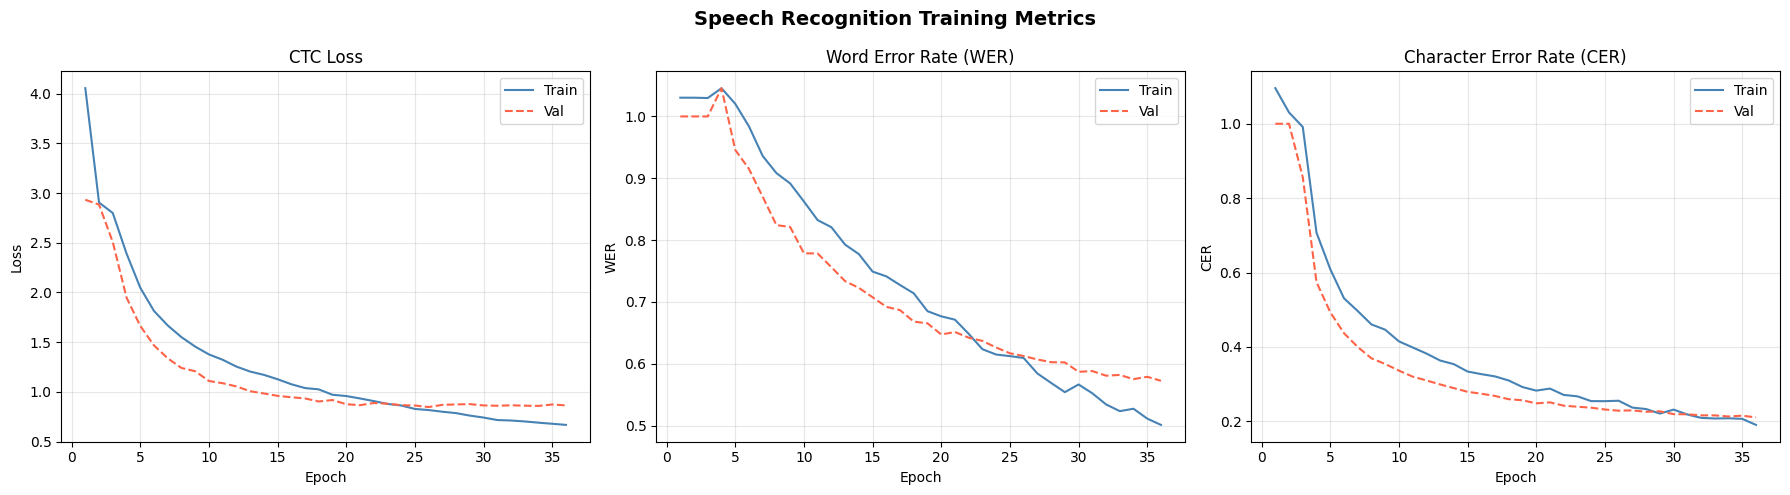

In [19]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='tomato', linestyle='--')
axes[0].set_title('CTC Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_wer'], label='Train', color='steelblue')
axes[1].plot(epochs, history['val_wer'],   label='Val',   color='tomato', linestyle='--')
axes[1].set_title('Word Error Rate (WER)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('WER')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['train_cer'], label='Train', color='steelblue')
axes[2].plot(epochs, history['val_cer'],   label='Val',   color='tomato', linestyle='--')
axes[2].set_title('Character Error Rate (CER)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('CER')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Speech Recognition Training Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=120)
plt.show()

In [20]:
import shutil, json, os


shutil.copy('/kaggle/working/best_model.pt', '/kaggle/working/best_model_final.pt')
print('✅ Model saved to /kaggle/working/best_model_final.pt')


with open('/kaggle/working/hparams.json', 'w') as f:
    json.dump(hparams, f, indent=2)
print('✅ Hparams saved to /kaggle/working/hparams.json')


with open('/kaggle/working/history.json', 'w') as f:
    json.dump(history, f, indent=2)
print('✅ History saved to /kaggle/working/history.json')

size = os.path.getsize('/kaggle/working/best_model_final.pt') / 1e6
print(f'\nCheckpoint size: {size:.1f} MB')
print('\nAll files in /kaggle/working:')
for f in os.listdir('/kaggle/working'):
    fsize = os.path.getsize(f'/kaggle/working/{f}') / 1e6
    print(f'  {f}  ({fsize:.1f} MB)')

✅ Model saved to /kaggle/working/best_model_final.pt
✅ Hparams saved to /kaggle/working/hparams.json
✅ History saved to /kaggle/working/history.json

Checkpoint size: 163.7 MB

All files in /kaggle/working:
  .virtual_documents  (0.0 MB)
  checkpoints  (0.0 MB)
  hparams.json  (0.0 MB)
  best_model.pt  (163.7 MB)
  training_curves.png  (0.1 MB)
  best_model_final.pt  (163.7 MB)
  history.json  (0.0 MB)


In [21]:
from jiwer import wer, cer
import random

print('Running inference on full val set for best/worst analysis...')

all_refs   = []
all_preds  = []

for r in val_records:
    try:
        waveform, sr = torchaudio.load(r['audio_path'])
        if sr != SAMPLE_RATE:
            waveform = T.Resample(sr, SAMPLE_RATE)(waveform)

        spec = val_audio_transform(waveform)
        spec = (spec - spec.mean()) / (spec.std() + 1e-9)
        spec = spec.unsqueeze(0).to(device)

        with torch.no_grad():
            log_probs    = model(spec)
            pred_indices = log_probs.argmax(dim=-1).squeeze(0).cpu().tolist()

        blank_idx = text_transform.blank_idx
        collapsed = []
        prev = None
        for idx in pred_indices:
            if idx != blank_idx and idx != prev:
                collapsed.append(idx)
            prev = idx

        pred = text_transform.int_to_text(collapsed)
        ref  = r['transcript'].lower().strip()

        all_refs.append(ref)
        all_preds.append(pred if pred else ' ')

    except Exception:
        continue


per_wer = [wer(r, p) for r, p in zip(all_refs, all_preds)]
per_cer = [cer(r, p) for r, p in zip(all_refs, all_preds)]

sorted_results = sorted(
    zip(all_refs, all_preds, per_wer, per_cer),
    key=lambda x: x[2]
)


print('\n' + '━' * 65)
print('  TOP 5 BEST PREDICTIONS')
print('━' * 65)
for ref, pred, w, c in sorted_results[:5]:
    print(f'  WER={w:.3f}  CER={c:.3f}')
    print(f'  REF : "{ref}"')
    print(f'  PRED: "{pred}"')
    print()


print('━' * 65)
print('  TOP 5 WORST PREDICTIONS')
print('━' * 65)
for ref, pred, w, c in sorted_results[-5:]:
    print(f'  WER={w:.3f}  CER={c:.3f}')
    print(f'  REF : "{ref}"')
    print(f'  PRED: "{pred}"')
    print()

print('━' * 65)
print(f'  Total samples   : {len(all_refs)}')
print(f'  Overall WER     : {wer(all_refs, all_preds):.4f}')
print(f'  Overall CER     : {cer(all_refs, all_preds):.4f}')
print(f'  Median WER      : {np.median(per_wer):.4f}')
print(f'  % perfect (0.0) : {np.mean(np.array(per_wer)==0)*100:.1f}%')
print('━' * 65)

Running inference on full val set for best/worst analysis...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TOP 5 BEST PREDICTIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  WER=0.000  CER=0.000
  REF : "spinning indeed"
  PRED: "spinning indeed"

  WER=0.000  CER=0.000
  REF : "but anders cared nothing about that"
  PRED: "but anders cared nothing about that"

  WER=0.000  CER=0.000
  REF : "explain yourself"
  PRED: "explain yourself"

  WER=0.000  CER=0.000
  REF : "so it seems to me"
  PRED: "so it seems to me"

  WER=0.000  CER=0.000
  REF : "you know him i think so"
  PRED: "you know him i think so"

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TOP 5 WORST PREDICTIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  WER=1.500  CER=0.650
  REF : "it is annoyance then"
  PRED: "he dis in' kno i antsthen"

  WER=1.500  CER=0.500
  REF : "marie sighed"
  PRED: "mo re side"

  WER=1.500  CER=0.714

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 File   : /kaggle/input/datasets/yasiashpot/librispeech/LibriSpeech/test-clean/237/134493/237-134493-0014.flac
 Speaker: 237  |  Chapter: 134493
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Audio:



 Ground Truth : "they think you're proud because you've been away to school or something"
 Prediction   : "theythink you a prowed because you ben away ti scol on or somephing"

 WER : 0.8333
 CER : 0.2254


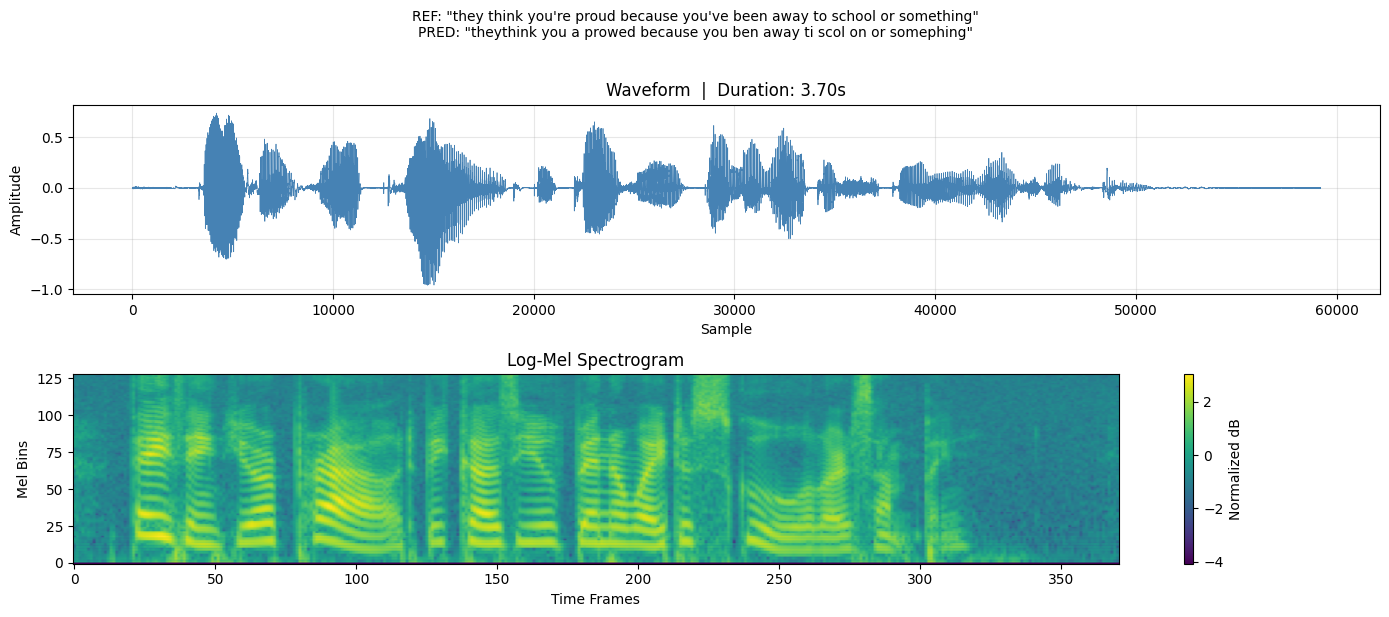


 Rerun this cell to get a different random sample!


In [22]:
import IPython.display as ipd
import random

r = random.choice(val_records)

print('━' * 65)
print(f' File   : {r["audio_path"]}')
print(f' Speaker: {r["speaker_id"]}  |  Chapter: {r["chapter_id"]}')
print('━' * 65)

print('\n Audio:')
display(ipd.Audio(r['audio_path']))


model.eval()
waveform, sr = torchaudio.load(r['audio_path'])
if sr != SAMPLE_RATE:
    waveform = T.Resample(sr, SAMPLE_RATE)(waveform)

spec = val_audio_transform(waveform)
spec = (spec - spec.mean()) / (spec.std() + 1e-9)
spec_input = spec.unsqueeze(0).to(device)

with torch.no_grad():
    log_probs    = model(spec_input)
    pred_indices = log_probs.argmax(dim=-1).squeeze(0).cpu().tolist()

blank_idx = text_transform.blank_idx
collapsed = []
prev = None
for idx in pred_indices:
    if idx != blank_idx and idx != prev:
        collapsed.append(idx)
    prev = idx

pred = text_transform.int_to_text(collapsed)
ref  = r['transcript'].lower().strip()

print(f'\n Ground Truth : "{ref}"')
print(f' Prediction   : "{pred}"')
print(f'\n WER : {wer(ref, pred) if pred.strip() else 1.0:.4f}')
print(f' CER : {cer(ref, pred) if pred.strip() else 1.0:.4f}')

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(waveform.squeeze().numpy(), color='steelblue', linewidth=0.5)
axes[0].set_title(f'Waveform  |  Duration: {waveform.shape[1]/SAMPLE_RATE:.2f}s')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

spec_plot = spec.squeeze().numpy()
img = axes[1].imshow(spec_plot, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('Log-Mel Spectrogram')
axes[1].set_xlabel('Time Frames')
axes[1].set_ylabel('Mel Bins')
plt.colorbar(img, ax=axes[1], label='Normalized dB')

plt.suptitle(f'REF: "{ref}"\nPRED: "{pred}"', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

print('\n Rerun this cell to get a different random sample!')